C:\Users\USER\AppData\Local\Temp\ipykernel_36992\1149202539.py:68: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  frame = plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, color='none', lw=3, edgecolor='black', linestyle='-', zorder=5, linewidth=2)


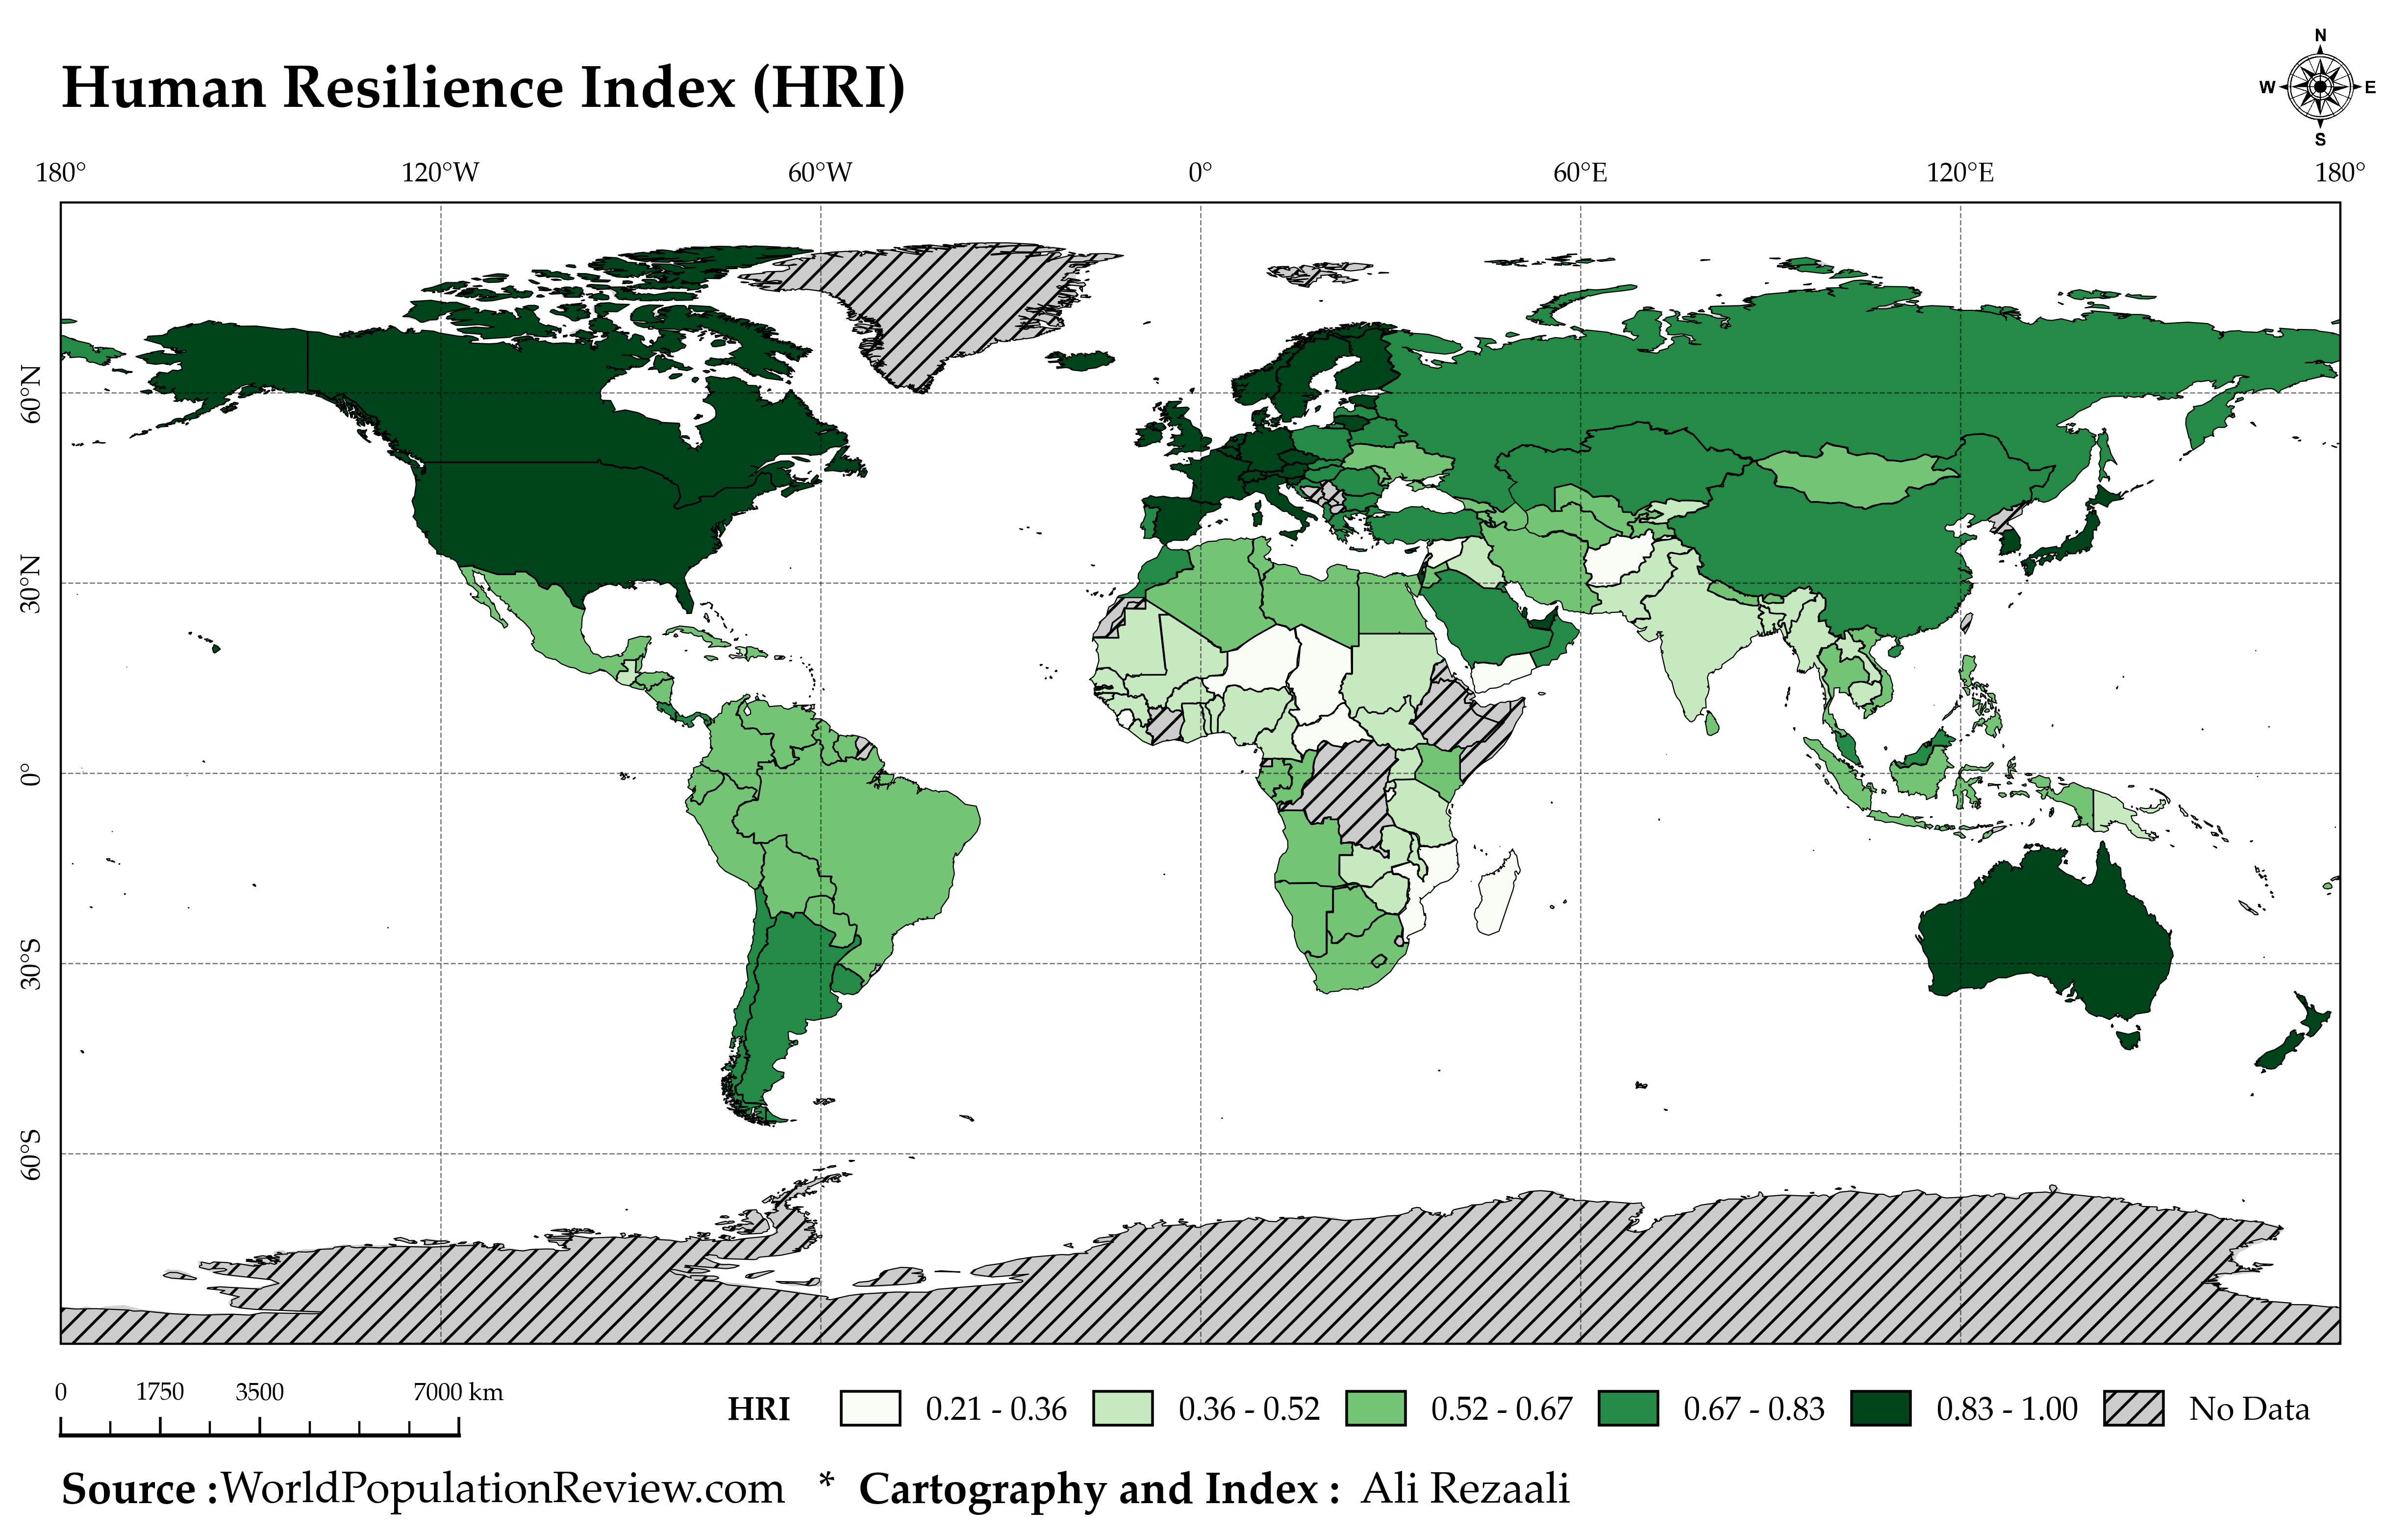

Image saved to: D:\Masters\1st Semester\Advanced GIS - پیشرفته GIS\Advanced GIS (II) Exercises\EX03\Files\Illustrations & Maps\HRI Final Map (Python).png


In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib_scalebar.scalebar import ScaleBar
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib import transforms
import matplotlib.font_manager as fm 

font_path = r"D:\Masters\1st Semester\Advanced GIS - پیشرفته GIS\Advanced GIS (II) Exercises\EX03\Files\Illustrations & Maps\pala.ttf"

fm.fontManager.addfont(font_path)

custom_font = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = custom_font.get_name()

# Load data

df = pd.read_csv(r"D:\Masters\1st Semester\Advanced GIS - پیشرفته GIS\Advanced GIS (II) Exercises\EX03\Files\MergedFiles.csv")  

world = gpd.read_file(r"D:\Masters\1st Semester\Advanced GIS - پیشرفته GIS\Advanced GIS (II) Exercises\EX03\Files\World Countries\WorldCountries.shp")

# Merge datasets

merged = world.merge(df, left_on="CNTRY_NAME", right_on="Country", how="left")

# Ensure correct column usage

merged.rename(columns={'GII_y': 'GII', 'GNI_y': 'GNI', 'EducationIndex': 'Education'}, inplace=True)

# Convert columns to numeric (force errors to NaN)

merged['Education'] = pd.to_numeric(merged['Education'], errors='coerce')

merged['GII'] = pd.to_numeric(merged['GII'], errors='coerce')

merged['GNI'] = pd.to_numeric(merged['GNI'], errors='coerce')


# Normalize GNI using log scale (avoid log(0) issues)

merged['LogGNI'] = np.log(merged['GNI'].replace(0, np.nan))  

min_log_gni = merged['LogGNI'].min()

max_log_gni = merged['LogGNI'].max()

merged['GNI_Norm'] = (merged['LogGNI'] - min_log_gni) / (max_log_gni - min_log_gni)

# Compute HRI ONLY if all three indices exist

merged['HRI'] = np.where(
    merged[['Education', 'GNI_Norm', 'GII']].notna().all(axis=1), 

    0.5 * merged['GNI_Norm'] + 0.3 * (1 - merged['GII']) + 0.2 * merged['Education'], 

    np.nan  # If any value is missing, set HRI to NaN
)

# Define class bins for HRI

bins = [0.2, 0.36, 0.52, 0.67, 0.83, 1.0]

labels = ["0.21 - 0.36", "0.36 - 0.52", "0.52 - 0.67", "0.67 - 0.83", "0.83 - 1.00"]

cmap = ListedColormap(["#f7fcf5", "#c6e9bf", "#73c475", "#248b46", "#00441b"])  # Green shades
norm = BoundaryNorm(bins, cmap.N)


# Set up the figure and axis

fig, ax = plt.subplots(figsize=(15, 10), dpi=400, subplot_kw={'projection': ccrs.PlateCarree()})

# Add map elements

ax.set_title("Human Resilience Index (HRI)", fontsize=22, fontweight='bold', loc='left', pad = 20)

ax.add_feature(cfeature.BORDERS, linewidth=0.6)

ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Plot the map with categorized colors

merged.plot(column="HRI", cmap=cmap, linewidth=0.4, edgecolor="black",

            legend=False, ax=ax, norm=norm,

            missing_kwds={"color": "#cccccc", "edgecolor": "black", "hatch": "///"})

# Add a rectangle frame around the map with rounded corners

frame = plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, color='none', lw=3, edgecolor='black', linestyle='-', zorder=5, linewidth=2)

ax.add_patch(frame)

# Add graticules (gridlines)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')

gl.top_labels = True

gl.left_labels = True

gl.right_labels = False

gl.bottom_labels = False

gl.ylabel_style = {'rotation': 90}  # This is the key line

# Add North arrow (properly positioned)

north_img = plt.imread(r"D:\Masters\1st Semester\Advanced GIS - پیشرفته GIS\Advanced GIS (II) Exercises\EX03\Files\Illustrations & Maps\North.png")

imagebox = OffsetImage(north_img, zoom=0.1)

ab = AnnotationBbox(imagebox, (0.99, 1.1),
                    xycoords='axes fraction',
                    frameon=False,
                    pad=0)
ax.add_artist(ab)

# Draw a line separating north arrow and HRI title

ax.add_line(plt.Line2D([0.5, 1.5], [0.99, 0.99], transform=fig.transFigure, color='black', lw=5, linestyle='--'))

# Scalebar implementation

meters_per_degree = 111320

total_length_m = 7_000_000

scalebar_y = -0.08

tick_height = 0.015

label_offset = 0.01

left_lon = -180

scalebar_length_deg = total_length_m / meters_per_degree

transform = transforms.blended_transform_factory(
    ax.transData,
    ax.transAxes
)

ax.plot(
    [left_lon, left_lon + scalebar_length_deg],
    [scalebar_y, scalebar_y],
    color='black', linewidth=1.5,
    transform=transform,
    clip_on=False
)

main_ticks = [
    (0, "0"),
    (1_750_000, "1750"),
    (3_500_000, "3500"),
    (7_000_000, "7000 km")
]

minor_ticks = [
    875_000, 2_625_000, 
    4_375_000, 5_250_000, 6_125_000
]

for pos_m, label in main_ticks:
    lon = left_lon + (pos_m / meters_per_degree)
    ax.plot(
        [lon, lon],
        [scalebar_y, scalebar_y + tick_height],
        color='black', linewidth=1,
        transform=transform,
        clip_on=False
    )
    ax.text(
        lon, scalebar_y + tick_height + label_offset,
        label,
        ha='center', va='bottom',
        transform=transform,
        fontsize=9, clip_on=False
    )

for pos_m in minor_ticks:
    lon = left_lon + (pos_m / meters_per_degree)
    ax.plot(
        [lon, lon],
        [scalebar_y, scalebar_y + (tick_height * 0.75)],
        color='black', linewidth=0.8,
        transform=transform,
        clip_on=False
    )


import matplotlib.patches as mpatches
legend_labels = ["HRI"] + labels  # Bold HRI label
legend_colors = [cmap(i / (cmap.N - 1)) for i in range(len(labels))]
legend_patches = [mpatches.Patch(color=legend_colors[i], label=legend_labels[i+1]) for i in range(len(labels))]

# Create patches for each category with black borders
legend_patches = [
    mpatches.Patch(facecolor=legend_colors[i], edgecolor="black", label=legend_labels[i + 1]) 
    for i in range(len(labels))
]

# Add the "No Data" category
legend_patches.append(mpatches.Patch(facecolor="#cccccc", edgecolor="black", hatch="///", label="No Data"))

# Insert "HRI" as an empty patch to act as a label in the same row
legend_patches.insert(0, mpatches.Patch(facecolor="none", edgecolor="none", label="HRI   ")) 

# Create the legend
legend = ax.legend(
    handles=legend_patches,
    loc="lower right",
    ncol=len(legend_patches),  # Ensures everything fits in one row
    bbox_to_anchor=(1, -0.1),
    frameon=False,
    prop={"size": 12},
    handleheight=1.2,  
    handlelength=1.8, 
    columnspacing=0.8,  
)

legend.get_texts()[0].set_fontweight("bold")



# Source text
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

bold_font_path = r"D:\Masters\1st Semester\Advanced GIS - پیشرفته GIS\Advanced GIS (II) Exercises\EX03\Files\Illustrations & Maps\palab.ttf"
fm.fontManager.addfont(bold_font_path)
bold_font = fm.FontProperties(fname=bold_font_path)



start_x = 0  
spacing = 0.02 

ax.text(start_x, -0.13, 'Source :', fontproperties=bold_font, 
        ha='left', va='center', transform=ax.transAxes, fontsize=16)

ax.text(start_x + 0.07, -0.13, 'WorldPopulationReview.com   *', 
        ha='left', va='center', transform=ax.transAxes, fontsize=16)

ax.text(start_x + 0.35, -0.13, 'Cartography and Index :', fontproperties=bold_font, 
        ha='left', va='center', transform=ax.transAxes, fontsize=16)

ax.text(start_x + 0.57, -0.13, 'Ali Rezaali', 
        ha='left', va='center', transform=ax.transAxes, fontsize=16)

plot_filename = "plot.png"
plt.savefig(plot_filename, bbox_inches='tight', pad_inches=0.1, dpi=400)

plt.show()

from PIL import Image, ImageDraw, ImageOps

# Function to apply rounded corners
def add_rounded_corners(img, radius = 150 ):
    width, height = img.size
    
    # Create a mask with rounded corners
    mask = Image.new('L', (width, height), 0)  # 'L' mode for grayscale
    draw = ImageDraw.Draw(mask)
    
    # Draw a rounded rectangle on the mask
    draw.rounded_rectangle((0, 0, width, height), radius, fill=255)
    
    # Apply the mask to the image
    img_with_rounded_corners = ImageOps.fit(img, (width, height), method=0, bleed=0.0, centering=(0.5, 0.5))
    img_with_rounded_corners.putalpha(mask)
    
    return img_with_rounded_corners

# Step 4: Add a horizontal line near the top
def add_horizontal_line(im, y_position, x_start, x_end, line_height=5, line_color="black"):
    """Adds a horizontal line to the image."""
    draw = ImageDraw.Draw(im)
    line_start = (x_start, y_position)  # Start at the provided x_start
    line_end = (x_end, y_position)  # End at the provided x_end
    draw.line([line_start, line_end], fill=line_color, width=line_height)
    return im

# Load the original image
image_path = r"C:\Users\USER\Desktop\plot.png"
img = Image.open(image_path)

# Apply the rounded corners to the original image
rounded_img = add_rounded_corners(img)

# Set parameters for the line
line_y_position = 185  # Vertical position of the line (near the top)
x_start = 2000  # Horizontal start position for the line
x_end = 4500  # Horizontal end position for the line
line_height = 5  # Height of the line (thickness)
line_color = "black"  # Line color

# Add the line to the image
rounded_img_with_line = add_horizontal_line(rounded_img, line_y_position, x_start, x_end, line_height, line_color)

# Add a black border to the image (5px width)
border_width = 5
border_color = (0, 0, 0)  # Black border
img_with_border = Image.new('RGBA', (rounded_img_with_line.width + 2 * border_width,
                                     rounded_img_with_line.height + 2 * border_width),
                           color=border_color)
img_with_border.paste(rounded_img_with_line, (border_width, border_width), rounded_img_with_line)

# Apply the same rounded corners effect to the bordered image
final_img_with_rounded_border = add_rounded_corners(img_with_border)

# Add white padding of 20px around the final image
padding = 100
final_img_with_padding = Image.new('RGBA', (final_img_with_rounded_border.width + 2 * padding,
                                            final_img_with_rounded_border.height + 2 * padding),
                                   color=(255, 255, 255, 255))  # White padding
final_img_with_padding.paste(final_img_with_rounded_border, (padding, padding), final_img_with_rounded_border)

# Save the final image
save_path = r"D:\Masters\1st Semester\Advanced GIS - پیشرفته GIS\Advanced GIS (II) Exercises\EX03\Files\Illustrations & Maps\HRI Final Map (Python).png"
final_img_with_padding.save(save_path)

# Show the final image
final_img_with_padding.show()

# Output the save path
print(f"Image saved to: {save_path}")

